In [2]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configuración visual
sns.set_theme(style="whitegrid")

# Unidad 6 - Ajustes y modelos 2

```{admonition} 📂 Descargar archivos  
[Descargar los archivos para la práctica desde el Campus Virtual](https://campusv.fceia.unr.edu.ar/course/view.php?id=471)
```
### **Ejercicio N°1**

El dataset `student_data.csv` contiene información sobre el promedio de horas semanales de estudio que un conjunto de estudiantes dedicó para la preparación de un examen y la calificación final recibida luego de rendirlo.

1. Realice un gráfico que le permita visualizar la relación existente entre las calificaciones finales y las horas de estudio del grupo de estudiantes. 
    
    ¿Cómo describiría dicha relación a partir de lo observado? 
    
    ¿Qué métrica utilizaría para cuantificar el grado de asociación lineal entre ambas variables? Calcúlela e interprete el valor obtenido.
    
2. A partir de los datos, ajuste un modelo de regresión lineal para la calificación final del examen en función de las horas semanales de estudio. Represente gráficamente el modelo ajustado en el gráfico realizado en el ítem 1.
3. Escriba el modelo ajustado en forma desarrollada e interprete cada uno de los coeficientes que lo componen.

In [7]:
estudiantes=pd.read_csv('./Datasets Práctica Nº 6/Parte_2/student_data.csv')
estudiantes.drop(columns='Unnamed: 0',inplace=True)

<Axes: xlabel='hours_studied', ylabel='exam_scores'>

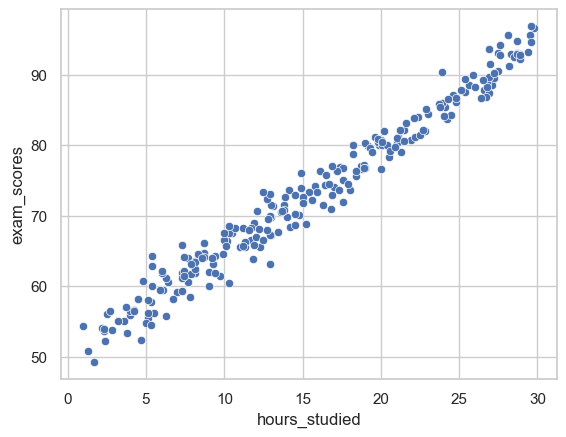

In [9]:
sns.scatterplot(x='hours_studied',y='exam_scores',data=estudiantes)

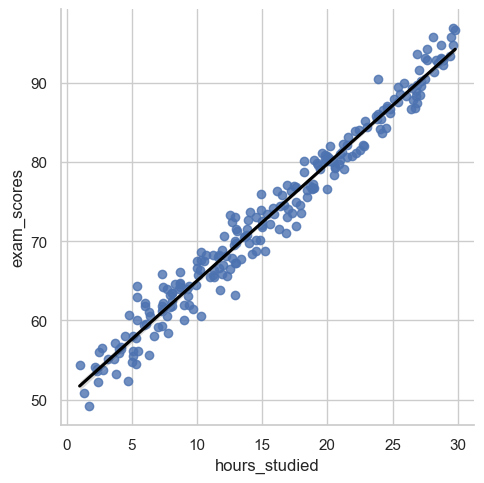

In [11]:
sns.lmplot(x='hours_studied',y='exam_scores',data=estudiantes,line_kws={'color':'black'})

In [8]:
estudiantes.corr()

,hours_studied,exam_scores
hours_studied,1.000000,0.986093
exam_scores,0.986093,1.000000


In [12]:
modelo = smf.ols(formula = 'exam_scores ~ hours_studied', data = estudiantes).fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:            exam_scores   R-squared:                       0.972
Model:                            OLS   Adj. R-squared:                  0.972
Method:                 Least Squares   F-statistic:                     8555.
Date:                Mon, 01 Jun 2026   Prob (F-statistic):          2.11e-191
Time:                        18:51:23   Log-Likelihood:                -512.26
No. Observations:                 245   AIC:                             1029.
Df Residuals:                     243   BIC:                             1036.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        50.2541      0.278    180.576

$\hat{y}= 50.2541+1.4750*x$

si no estudian se sacan 50.254 y a medida que estudien es mas probable que aprueben

### **Ejercicio N°2**

Supongamos que ajustamos un modelo de regresión lineal por mínimos cuadrados para el precio de una propiedad en moneda local (\$, peso local) en función de los siguientes predictores: superficie en metros cuadrados ($x_1$), cantidad de habitaciones ($x_2$), antigüedad en años ($x_3$), y ubicación ($x_4$, codificada de la siguiente manera: 0 para ámbito urbano y 1 para suburbano). Obtenemos los siguientes coeficientes:

- $\hat{\beta_0} = 10000$
- $\hat{\beta_1} = 5000$
- $\hat{\beta_2} = 2000$
- $\hat{\beta_3} = -1500$
- $\hat{\beta_4} = - 15000$
1. Escriba la ecuación del modelo ajustado en forma desarrollada.
2. A partir del modelo ajustado, ¿cuál de las siguientes afirmaciones es correcta y por qué?
    1. Para un mismo número de habitaciones, antigüedad y metros cuadrados, las propiedades en áreas suburbanas son más caras, en promedio, que las que se encuentran en áreas urbanas.
    2. Para viviendas ubicadas en el área urbana con una misma antigüedad y superficie, el precio predicho por el modelo se incrementa, en promedio, en $10000 por cada año de antigüedad.
    3. El número de habitaciones es una variable que tiene “más peso” sobre el precio de la propiedad en viviendas en áreas urbanas que en aquellas que se encuentran en áreas suburbanas.
    4. El modelo predice que una propiedad ubicada en el área urbana cuesta $15000 más que una propiedad de la misma superficie, antigüedad y cantidad de habitaciones que se encuentre en el área suburbana.

### **Ejercicio N°3**

El dataset `penguins` es un conjunto de datos sobre pingüinos de tres especies diferentes que anidan en una colonia de Archipiélago Palmer, en la Antártida. Contiene información sobre las medidas corporales de los pingüinos, incluyendo la longitud y profundidad del pico (`bill_length_mm` y `bill_depth_mm` , respectivamente), la longitud de la aleta (`flipper_length_mm`) y la masa corporal (`body_mass_g`), así como información sobre el sexo.

1. Realice un gráfico que le permita visualizar la relación que existe entre la longitud del pico y la longitud de la aleta de los pingüinos Palmer, según la especie. ¿Qué observa?
2. Ajuste un modelo de regresión lineal que le permita predecir la longitud promedio del pico de los pingüinos Palmer a partir de la longitud de la aleta (**modelo 1**).
3. A partir de las observaciones que realizó en el ítem 1, introduzca alguna modificación sobre el modelo inicial que le permita mejorar su capacidad predictiva para la longitud del pico de los pingüinos. 
Ajuste el nuevo modelo propuesto (**modelo 2**). 
4. ¿Cuál de los dos modelos (**modelo 1, modelo 2**) proporciona un mejor ajuste? ¿Qué métrica utilizó para compararlos?
5. Utilice el modelo seleccionado en el ítem anterior para predecir la longitud de pico que tendrá un pingüino Chinstrap de 17.6 mm de profundidad de pico, 191 mm de longitud de aleta, 3125 g de masa corporal y sexo masculino.

### **Ejercicio N°4**

Utilizando el dataset `dataset_rendimiento.csv`, que contiene información sobre 235 estudiantes universitarios de segundo año de una institución universitaria en relación a las horas semanales promedio de estudio dedicadas, el tipo de desayuno que consumen antes de los exámenes y el rendimiento medio en los exámenes parciales:

1. Ajuste un modelo de regresión lineal que permita predecir el rendimiento promedio de estudiantes de segundo año a partir del número de horas semanales promedio de estudio y el tipo de desayuno que consumen. 
2. ¿Cuál/es de las variables incluidas contribuye/n significativamente a explicar el rendimiento de los estudiantes? Justifique.
3. Utilizando el modelo ajustado, prediga el rendimiento promedio que presentará un estudiante que dedica, en promedio, 5.5 horas semanales de estudio y posee la costumbre de consumir un desayuno saludable previo a las instancias de examen.

### **Ejercicio N°5**

Un cliente lo contrató como científico de datos para que estudie la posible asociación entre la inversión en publicidad que realiza su empresa y las ventas de un producto particular. El conjunto de datos de publicidad `advertising.csv` contiene información acerca de las ventas de ese producto en 200 mercados diferentes, junto con presupuestos publicitarios para el producto para tres medios diferentes: televisión, radio y periódicos/diarios.

1. ¿El presupuesto publicitario invertido en qué medio de comunicación se encuentra más fuertemente asociado con mayores ventas del producto?
2. Ajuste un modelo de regresión lineal que permita predecir las ventas promedio del producto en cuestión en función de los presupuestos publicitarios destinados a TV, radio y periódicos. En función de los resultados obtenidos, realice las modificaciones que considere adecuadas para quedarse con el mejor modelo ajustado y justifique cada decisión que tome.
3. Escriba la ecuación del modelo ajustado en forma desarrollada e interprete el coeficiente correspondiente a la variable `TV`.
4. Realice un gráfico para representar la distribución de los residuos del modelo y comente brevemente las características de la misma. ¿Podría suponerse que se cumple el supuesto de normalidad?

### **Ejercicio N°6**

El dataset `auto.xlsx` contiene información sobre 392 autos de distintas marcas y modelos. Entre las características registradas se encuentran: el consumo en millas por galón (`mpg`), caballos de fuerza (`horsepower`), peso en libras (`weight`) y la marca y el modelo (`name`).

1. ¿Qué porcentaje de los autos del dataset pertenecen a la marca **Ford**?
2. Realice un gráfico que le permita visualizar la distribución de los autos del dataset en función de su origen. Para ello, tenga en cuenta que dicha información se encuentra en la columna `origin`, codificada de la siguiente manera: 1= americano, 2 = europeo y 3 = japonés.
3. Ajuste un modelo de regresión lineal simple considerando al consumo del vehículo como la variable respuesta y a los caballos de fuerza como único predictor. En base a los resultados obtenidos responda:
    1. ¿La relación entre la variable respuesta y la explicativa es positiva o negativa?
    2. ¿Cómo interpreta el valor del coeficiente correspondiente a la variable `horsepower`?
    3. ¿Qué porcentaje de la variabilidad en el consumo de los vehículos es explicada por el modelo de regresión que ajustó?
4. Realice un gráfico para visualizar la relación que existe entre las variables `mpg` y `horsepower` en el dataset y represente sobre el mismo el ajuste realizado en el ítem anterior.  ¿Encuentra alguna falencia o limitación en el modelo propuesto? Justifique
5. Si su respuesta al ítem fue afirmativa, ¿cómo podría mejorar el modelo para resolver las limitaciones o falencias encontradas?

### **Ejercicio N°7**

El dataset `USA_Housing.xlsx` contiene la siguiente información sobre un conjunto de 5000 viviendas en Estados Unidos:

- **avg_area_income:** ingreso promedio de los residentes de la ciudad en la que se encuentra la vivienda.
- **avg_area_house_age:** antigüedad promedio de las casas que se encuentran en la misma ciudad en la que se encuentra la vivienda.
- **avg_area_number_of_rooms:** número promedio de ambientes en las casas que se encuentran en la misma ciudad en la que se encuentra la vivienda.
- **avg_area_number_of_bedrooms:** número promedio de habitaciones en las casas que se encuentran en la misma ciudad de la vivienda.
- **area_population:** población de la ciudad de la vivienda.
- **price:** precio de venta de la vivienda.
- **address:** domicilio de la vivienda.

**PARTE I - Análisis exploratorio**

1. Importe el dataset al entorno de trabajo y realice cualquier tarea de limpieza y adecuación del mismo que considere necesaria para su posterior análisis.
2. Realice un gráfico que le permita visualizar la distribución del precio de venta de las residencias que componen el dataset. En base al gráfico realizado, ¿cómo describiría la distribución de la variable en cuanto a sus características de simetría?
3. Construya un gráfico que le permita evaluar el grado de asociación lineal que existe entre las distintas variables cuantitativas que componen el dataset. En base al mismo, identifique la/s variable/s que se encuentran más fuertemente correlacionadas e informe e interprete la medida de asociación lineal correspondiente.
4. Elija uno de los pares de variables que identificó en el ítem anterior y realice un gráfico que le permita visualizar la relación general que existe entre las mismas.

**PARTE II - Ajuste de modelo**

El objetivo principal de esta segunda parte es analizar si es factible ajustar un modelo de regresión lineal que permita predecir el precio de venta de una vivienda en Estados Unidos a partir de la cantidad de personas que viven en la ciudad en la que ésta se ubica y su ingreso promedio, así como las características generales de las viviendas en dicho lugar (antigüedad promedio/número promedio de ambientes/número de habitaciones promedio).

1. Comience ajustando el modelo completo, incluyendo la totalidad de las variables explicativas o independientes que resultan de interés. ¿Cuál/es de las variables incluidas contribuye/n significativamente a explicar la calidad de los vinos? Justifique.
2. Ajuste un nuevo modelo tomando en cuenta su respuesta a la pregunta anterior. 
- En base al ajuste realizado, escriba dicho modelo en forma desarrollada e interprete cada uno de los coeficientes.
- ¿Qué medida utilizaría para comparar los dos modelos en cuanto a su bondad de ajuste? Interprete dicha medida para el modelo final.
- Realice un gráfico de valores predichos vs. valores reales y comente lo observado.